In [1]:
!pip install -q transformers datasets accelerate torch scikit-learn fairlearn aif360 pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 23.0 MB/s eta 0:00:00


In [2]:
!pip install aif360[inFairness]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.7 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import AutoTokenizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
from sklearn.calibration import CalibratedClassifierCV

from fairlearn.postprocessing import ThresholdOptimizer
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import ClassificationMetric

BASE_MODEL = "distilbert-base-uncased"
MAX_LENGTH = 128

print("Required libraries imported.")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"PyTorch version: {torch.__version__}")

/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vect_ndcg = vmap(vect_normalized_discounted

Required libraries imported.
CUDA available: True
PyTorch version: 2.10.0+cu128


# Part 1 - Data Loading, Label Binarization, and Stratified Splits

This notebook performs the required preprocessing steps:
- Load the Jigsaw unintended bias training CSV
- Binarize `toxic` using threshold >= 0.5
- Create a 100,000-row training subset and 20,000-row held-out evaluation subset
- Use stratified random sampling on the binarized label
- Verify no leakage between train and eval

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TRAIN_SIZE = 100_000
EVAL_SIZE = 20_000

INPUT_PATH = "jigsaw-unintended-bias-train.csv"
TRAIN_OUT_PATH = "train_subset_100k.csv"
EVAL_OUT_PATH = "eval_subset_20k.csv"

print("Config loaded.")

Config loaded.


In [5]:
# Load only the columns needed for this stage to keep memory usage lower.
cols_needed = [
    "comment_text",
    "toxic",
    "black",
    "white",
    "muslim",
    "jewish",
]

df = pd.read_csv(INPUT_PATH, usecols=cols_needed)
df = df.reset_index(drop=False).rename(columns={"index": "row_id"})

# Required label binarization: toxic >= 0.5 -> 1, else 0.
df["label"] = (df["toxic"] >= 0.5).astype(int)

print(f"Rows loaded: {len(df):,}")
print("Overall class distribution (label):")
print(df["label"].value_counts(normalize=True).sort_index())

Rows loaded: 1,902,194
Overall class distribution (label):
label
0    0.920034
1    0.079966
Name: proportion, dtype: float64


In [6]:
if len(df) < (TRAIN_SIZE + EVAL_SIZE):
    raise ValueError("Dataset does not contain enough rows for requested subset sizes.")

# First carve out held-out evaluation set from the full dataset.
remaining_df, eval_df = train_test_split(
    df,
    test_size=EVAL_SIZE,
    stratify=df["label"],
    random_state=RANDOM_STATE,
)

# Then draw the fixed-size training subset from the remaining pool.
train_df, _ = train_test_split(
    remaining_df,
    train_size=TRAIN_SIZE,
    stratify=remaining_df["label"],
    random_state=RANDOM_STATE,
)

assert len(train_df) == TRAIN_SIZE
assert len(eval_df) == EVAL_SIZE

# Leakage check: row_id sets must be disjoint.
overlap = set(train_df["row_id"]).intersection(set(eval_df["row_id"]))
print(f"Train rows: {len(train_df):,}")
print(f"Eval rows:  {len(eval_df):,}")
print(f"Overlap rows between train and eval: {len(overlap)}")
if overlap:
    raise RuntimeError("Leakage detected: train/eval overlap is non-zero.")

Train rows: 100,000
Eval rows:  20,000
Overlap rows between train and eval: 0


In [7]:
def class_balance(frame, name):
    dist = frame["label"].value_counts(normalize=True).sort_index()
    print(f"\n{name} class distribution (label):")
    print(dist)

class_balance(df, "Full")
class_balance(train_df, "Train")
class_balance(eval_df, "Eval")


Full class distribution (label):
label
0    0.920034
1    0.079966
Name: proportion, dtype: float64

Train class distribution (label):
label
0    0.92003
1    0.07997
Name: proportion, dtype: float64

Eval class distribution (label):
label
0    0.92005
1    0.07995
Name: proportion, dtype: float64


In [8]:
# Save artifacts for downstream modeling and audits.
train_df.to_csv(TRAIN_OUT_PATH, index=False)
eval_df.to_csv(EVAL_OUT_PATH, index=False)

print(f"Saved train subset to: {TRAIN_OUT_PATH}")
print(f"Saved eval subset to:  {EVAL_OUT_PATH}")

Saved train subset to: train_subset_100k.csv
Saved eval subset to:  eval_subset_20k.csv


## Step 3 - Initialize DistilBERT and Tokenize

This step initializes `distilbert-base-uncased` and tokenizes `comment_text` with `max_length=128` and `truncation=True`.

In [9]:
import numpy as np
import torch
from datasets import Dataset
from transformers import AutoTokenizer

BASE_MODEL = "distilbert-base-uncased"
MAX_LENGTH = 128

print("Tokenization config loaded.")
print(f"CUDA available: {torch.cuda.is_available()}")

Tokenization config loaded.
CUDA available: True


In [10]:

try:
    train_df
    eval_df
except NameError:
    import pandas as pd
    train_df = pd.read_csv("train_subset_100k.csv")
    eval_df = pd.read_csv("eval_subset_20k.csv")

train_hf = Dataset.from_pandas(
    train_df[["comment_text", "label"]].reset_index(drop=True)
)
eval_hf = Dataset.from_pandas(
    eval_df[["comment_text", "label"]].reset_index(drop=True)
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize_batch(batch):
    return tokenizer(
        batch["comment_text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_tok = train_hf.map(tokenize_batch, batched=True, remove_columns=["comment_text"])
eval_tok = eval_hf.map(tokenize_batch, batched=True, remove_columns=["comment_text"])

train_tok = train_tok.rename_column("label", "labels")
eval_tok = eval_tok.rename_column("label", "labels")

train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
eval_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print("Tokenization done.")
print(train_tok)
print(eval_tok)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Tokenization done.
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 100000
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 20000
})


## Step 4 - Fine-tune DistilBERT with Trainer API

This step fine-tunes distilbert-base-uncased for 3 epochs using HuggingFace Trainer with standard cross-entropy loss.

In [11]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

MODEL_OUT_DIR = "distilbert_toxicity_checkpoint_part1"
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
BATCH_SIZE = 16

# Use dynamic padding at batch time.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "auc_roc": roc_auc_score(labels, probs),
    }

model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2)

base_args = dict(
    output_dir=MODEL_OUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    save_strategy="epoch",
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="eval_auc_roc",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    seed=RANDOM_STATE,
    report_to="none",
)

# transformers versions differ: some use evaluation_strategy, newer builds use eval_strategy.
try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        **base_args,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        **base_args,
    )

# transformers versions differ: some Trainer builds accept `tokenizer`, newer builds removed it.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=eval_tok,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=eval_tok,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

print("Trainer initialized. Ready to train for 3 epochs.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer initialized. Ready to train for 3 epochs.


In [12]:
train_result = trainer.train()
print(train_result)

trainer.save_model(MODEL_OUT_DIR)
tokenizer.save_pretrained(MODEL_OUT_DIR)

print(f"Model checkpoint saved to: {MODEL_OUT_DIR}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Auc Roc
1,0.158548,0.154901,0.948100,0.807168,0.945552
2,0.108062,0.159872,0.947350,0.812847,0.946246
3,0.056185,0.226740,0.947100,0.812354,0.942421


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=18750, training_loss=0.11801475128173829, metrics={'train_runtime': 1439.2705, 'train_samples_per_second': 208.439, 'train_steps_per_second': 13.027, 'total_flos': 9848586804727296.0, 'train_loss': 0.11801475128173829, 'epoch': 3.0})


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model checkpoint saved to: distilbert_toxicity_checkpoint_part1


## Step 5 - Evaluate on Held-Out Set

This step reports Accuracy, macro F1, AUC-ROC, and the confusion matrix on the 20,000-row evaluation subset.

Run training first, then execute these cells.

Evaluation metrics at threshold = 0.5
Accuracy:   0.9474
F1 (macro): 0.8128
AUC-ROC:   0.9463
Confusion matrix [[TN, FP], [FN, TP]]:
[[17951   450]
 [  603   996]]


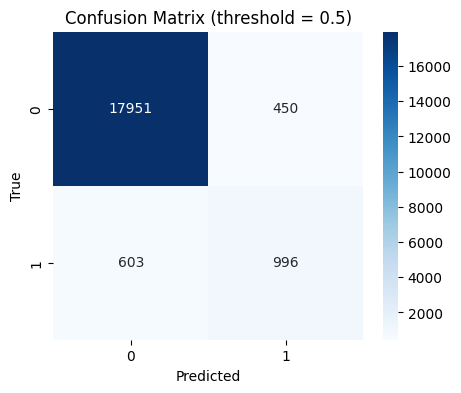

In [13]:
pred_output = trainer.predict(eval_tok)
logits = pred_output.predictions
y_true = pred_output.label_ids

y_prob = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
y_pred_05 = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_true, y_pred_05)
f1_macro = f1_score(y_true, y_pred_05, average="macro")
auc = roc_auc_score(y_true, y_prob)
cm = confusion_matrix(y_true, y_pred_05)

print("Evaluation metrics at threshold = 0.5")
print(f"Accuracy:   {acc:.4f}")
print(f"F1 (macro): {f1_macro:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (threshold = 0.5)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Step 6 - Plot ROC and Precision-Recall Curves

This step plots the ROC curve and Precision-Recall curve on the held-out evaluation subset.

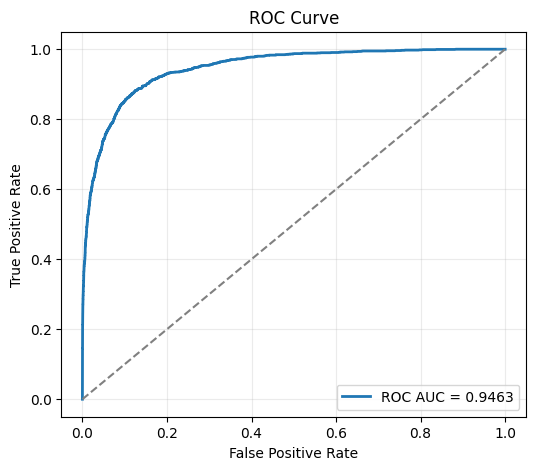

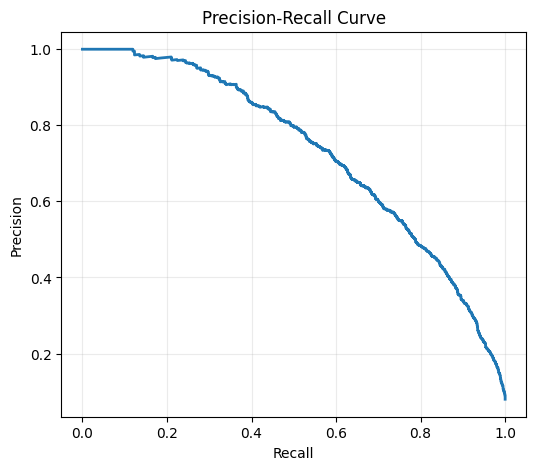

In [14]:
# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc_val = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_val:.4f}", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, linewidth=2)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.25)
plt.show()

## Step 7 - Threshold Sweep and Operating Threshold Decision

This step compares F1 across thresholds {0.3, 0.4, 0.5, 0.6, 0.7} and selects one operating threshold for the rest of the assignment.

,threshold,f1_macro,accuracy,precision_pos,positive_rate
0,0.3,0.811265,0.94325,0.638425,0.08380
1,0.4,0.809228,0.94480,0.660610,0.07705
2,0.5,0.812847,0.94735,0.688797,0.07230
3,0.6,0.810162,0.94795,0.704846,0.06810
4,0.7,0.810806,0.94950,0.730619,0.06385


Chosen operating threshold: 0.5
Best macro F1: 0.8128


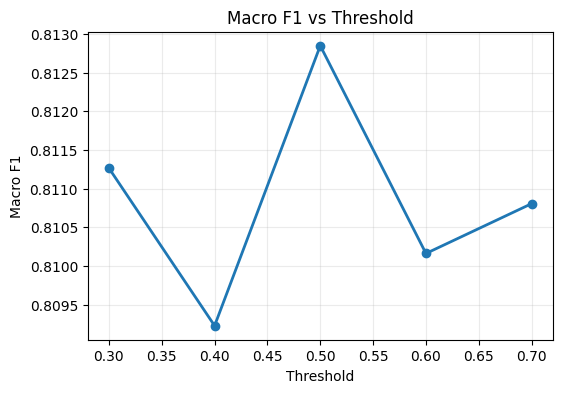

In [15]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    rows.append({
        "threshold": t,
        "f1_macro": f1_score(y_true, y_pred_t, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred_t),
        "precision_pos": (y_true[y_pred_t == 1].mean() if np.sum(y_pred_t == 1) > 0 else 0.0),
        "positive_rate": float(np.mean(y_pred_t)),
    })

threshold_results = pd.DataFrame(rows)
display(threshold_results)

# Select threshold by highest macro F1; if tied, choose the lower threshold to reduce missed toxicity.
best_f1 = threshold_results["f1_macro"].max()
candidates = threshold_results[threshold_results["f1_macro"] == best_f1].sort_values("threshold")
OPERATING_THRESHOLD = float(candidates.iloc[0]["threshold"])

print(f"Chosen operating threshold: {OPERATING_THRESHOLD:.1f}")
print(f"Best macro F1: {best_f1:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(threshold_results["threshold"], threshold_results["f1_macro"], marker="o", linewidth=2)
plt.title("Macro F1 vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Macro F1")
plt.grid(alpha=0.25)
plt.show()

## Threshold Justification and Platform Priority

For the rest of this assignment, we use the threshold chosen in Step 7 (`OPERATING_THRESHOLD`), selected by maximum macro F1 over {0.3, 0.4, 0.5, 0.6, 0.7}. If multiple thresholds tie, we choose the lower threshold.

Policy position:
- This choice prioritizes a balanced baseline across both classes (macro F1), rather than optimizing only for accuracy.
- The tie-break toward a lower threshold reflects a Trust and Safety preference to reduce false negatives (missed toxic content), accepting some increase in false positives.
- In practice, this means the platform is slightly more protective against harmful content exposure, while still controlling over-moderation by anchoring the decision to macro F1 rather than recall alone.

This threshold is a baseline operating point for Part 1. Later fairness and robustness mitigations (reweighing, threshold optimization, adversarial hardening) may justify revisiting it.

In [ ]:
import shutil
from google.colab import files

# Zip the checkpoint folder
shutil.make_archive(MODEL_OUT_DIR, 'zip', MODEL_OUT_DIR)

# Download the zipped file
files.download(f'{MODEL_OUT_DIR}.zip')